# LoGIC: Lossy Gaussian Interferometer Computation

This notebook provides a compact tour of the current LoGIC project.

LoGIC propagates Gaussian states through programmable linear-optical interferometers using the symplectic formalism. The project supports three interferometer descriptions:

- `Clements`: square mesh decomposition
- `Reck`: triangular mesh decomposition
- `embedded_reck`: a Reck circuit embedded into a larger Clements mesh with explicit identity beam splitters and vacuum ancilla modes

The notebook focuses on the current public API and demonstrates how to work with the project in practice.

## Project overview

The most important entry points are:

- `devices.py`
  - `GaussianDevice`: state propagation through a beamsplitter network
  - `random_squeezed_vacuum(...)`: helper for Gaussian input states
  - `build_instructions(...)`: random network generator for the supported topologies
- `pipeline.py`
  - `get_Vout(...)`: high-level propagation from a target unitary
  - `instructions_from_U(...)`: decomposition of a target unitary into network instructions

For `embedded_reck`, LoGIC automatically handles:

- enlargement to a larger Clements mesh
- explicit identity beam splitters
- prepended vacuum ancilla modes
- reduction back to the logical system modes

If `embedded_total_modes` is not specified, the default embedded mesh size is the smallest validated size

$$N_{\mathrm{total}} = 2n - 2$$

for a logical `n`-mode Reck circuit.

In [73]:
import importlib
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import unitary_group

import devices
import pipeline

importlib.reload(devices)
importlib.reload(pipeline)

from devices import (
    GaussianDevice,
    build_instructions,
    embedded_reck_mode_count,
    effective_loss_curve,
    random_squeezed_vacuum,
    squeezed_vacuum,
)
from pipeline import get_Vout, instructions_from_U

np.set_printoptions(precision=4, suppress=True)

In [74]:
def haar_unitary(n: int, rng: np.random.Generator) -> np.ndarray:
    """Generate a Haar-random unitary."""
    return unitary_group.rvs(n, random_state=rng)

## 1. Build a Gaussian input state

LoGIC works with the Gaussian state described by a mean vector `d` and covariance matrix `V` in quadrature ordering

$$(x_0, \ldots, x_{n-1}, p_0, \ldots, p_{n-1}).$$

A convenient starting point is a random squeezed-vacuum input.

In [75]:
rng = np.random.default_rng(42)
modes = 4

d0, V0 = random_squeezed_vacuum(modes, rng=rng)
input_device = GaussianDevice(d0.copy(), V0.copy(), instructions=())

print('mean-vector shape:', d0.shape)
print('covariance shape:', V0.shape)
print('input photon number:', input_device.exp_photon_number())
print('input first cumulants:', input_device.first_cumulants())

mean-vector shape: (8,)
covariance shape: (8, 8)
input photon number: 1.962335282150204
input first cumulants: [0.551  0.295  0.6331 0.4832]


## 2. Direct `GaussianDevice` usage

If you already have a list of beamsplitter instructions, you can work directly with `GaussianDevice`.

The helper `GaussianDevice.from_logical_state(...)` is especially useful because it handles the `embedded_reck` ancilla bookkeeping automatically while keeping the external interface at the logical-system level.

In [76]:
rng = np.random.default_rng(123)
modes = 5
topology = 'embedded_reck'
eta = 1.0

instructions = build_instructions(
    modes,
    topology,
    rng=rng,
    include_phases=False,
)
logical_output_phases = rng.uniform(0.0, 2.0 * np.pi, size=modes)

d_in, V_in = random_squeezed_vacuum(modes, rng=rng)
device = GaussianDevice.from_logical_state(
    d=d_in,
    V=V_in,
    instructions=instructions,
    topology=topology,
    rng=rng,
)

d_out, V_out = device.run(eta=eta, output_phases=logical_output_phases, logical_output=True)
output_device = GaussianDevice(d_out, V_out, instructions=())

print('physical device modes:', device.n)
print('logical modes:', device.logical_modes)
print('output covariance shape:', V_out.shape)
print('output photon number:', output_device.exp_photon_number())
print('output first cumulants:', output_device.first_cumulants())

physical device modes: 8
logical modes: (3, 4, 5, 6, 7)
output covariance shape: (10, 10)
output photon number: 2.2385373780572957
output first cumulants: [0.2557 0.4241 0.5487 0.515  0.4951]


## 3. Random instruction lists for the three topologies

`build_instructions(...)` can generate random network instructions directly. The instruction count reflects the underlying geometry.

In [77]:
rng = np.random.default_rng(77)
modes = 6

for topo in ['Clements', 'Reck', 'embedded_reck']:
    instructions = build_instructions(modes, topo, rng=rng, include_phases=True)
    print(f'{topo:13s} instruction_count = {len(instructions)}')
    print('  first two instructions =', instructions[:2])

Clements      instruction_count = 15
  first two instructions = ((0, 1, 4.938158333471926, 3.463115534413977), (2, 3, 1.5323947356923642, 2.101431472881218))
Reck          instruction_count = 15
  first two instructions = ((0, 1, 0.5456917854892854), (1, 2, 0.21502487125010505))
embedded_reck instruction_count = 45
  first two instructions = ((0, 1, 0.0, 0.0), (2, 3, 0.0, 0.0))


## 4. Propagation from a target unitary

When the starting point is a target unitary `U`, the easiest interface is `pipeline.get_Vout(...)`. It decomposes the unitary according to the chosen topology, propagates the Gaussian state, and returns the output `(d, V)`.

In [78]:
rng = np.random.default_rng(7)
modes = 6
U = haar_unitary(modes, rng)
d0, V0 = random_squeezed_vacuum(modes, rng=rng)

for topo in ['Clements', 'Reck', 'embedded_reck']:
    d_out, V_out = get_Vout(U, V0, d0=d0, eta=1.0, topology=topo)
    print(f'{topo:13s} output covariance shape = {V_out.shape}')

Clements      output covariance shape = (12, 12)
Reck          output covariance shape = (12, 12)
embedded_reck output covariance shape = (12, 12)


## 5. Equivalence in the unitary / lossless case

For a fixed target unitary and no loss, the three topologies should produce the same logical Gaussian output state.

In [79]:
rng = np.random.default_rng(2026)
modes = 10
U = haar_unitary(modes, rng)
d0, V0 = random_squeezed_vacuum(modes, rng=rng)

outputs = {}
for topo in ['Clements', 'Reck', 'embedded_reck']:
    outputs[topo] = get_Vout(U, V0, d0=d0, eta=1.0, topology=topo)

d_c, V_c = outputs['Clements']
d_r, V_r = outputs['Reck']
d_e, V_e = outputs['embedded_reck']

print('|d_C - d_R| =', np.linalg.norm(d_c - d_r))
print('|d_C - d_E| =', np.linalg.norm(d_c - d_e))
print('|V_C - V_R| =', np.linalg.norm(V_c - V_r))
print('|V_C - V_E| =', np.linalg.norm(V_c - V_e))

|d_C - d_R| = 0.0
|d_C - d_E| = 0.0
|V_C - V_R| = 3.52587161791455e-15
|V_C - V_E| = 3.4030853232299013e-15


## 6. Embedded-Reck mesh size

You can choose a larger physical Clements mesh via `embedded_total_modes`, provided it satisfies

$$N_{\mathrm{total}} \ge 2n - 2.$$

The default is the smallest validated size.

In [80]:
rng = np.random.default_rng(314)
modes = 7
U = haar_unitary(modes, rng)

for total in [None, 12, 13, 14]:
    instructions, phases = instructions_from_U(U, 'embedded_reck', embedded_total_modes=total)
    embedded_n = embedded_reck_mode_count(modes, total)
    print(f'embedded_total_modes={total}, physical_modes={embedded_n}, instruction_count={len(instructions)}, phase_count={len(phases)}')

embedded_total_modes=None, physical_modes=12, instruction_count=66, phase_count=12
embedded_total_modes=12, physical_modes=12, instruction_count=66, phase_count=12
embedded_total_modes=13, physical_modes=13, instruction_count=78, phase_count=13
embedded_total_modes=14, physical_modes=14, instruction_count=91, phase_count=14


## 7. Compare the logical unitary of `embedded_reck` with `Reck`

The following cell reconstructs the unitary implemented by the plain Reck circuit and compares it with the logical system block of the embedded-Reck device.

In [81]:
rng = np.random.default_rng(555)
modes = 8
U = haar_unitary(modes, rng)

inst_r, ph_r = instructions_from_U(U, 'Reck')
plain_reck = GaussianDevice(np.zeros(2 * modes), 0.5 * np.eye(2 * modes), instructions=inst_r)
U_reck = np.diag(np.exp(1j * np.asarray(ph_r))) @ plain_reck.get_unitary()

inst_e, ph_e = instructions_from_U(U, 'embedded_reck')
embedded_n = embedded_reck_mode_count(modes)
n_anc = embedded_n - modes
embedded_reck = GaussianDevice.from_logical_state(
    d=np.zeros(2 * modes),
    V=0.5 * np.eye(2 * modes),
    instructions=inst_e,
    topology='embedded_reck',
)
U_emb = np.diag(np.exp(1j * np.asarray(ph_e))) @ embedded_reck.get_unitary()
U_sys = U_emb[n_anc:n_anc + modes, n_anc:n_anc + modes]

print('embedded physical modes:', embedded_n)
print('|U_reck - U_embedded(system block)| =', np.linalg.norm(U_reck - U_sys))

embedded physical modes: 14
|U_reck - U_embedded(system block)| = 2.666738892289582e-16


## 8. Lossy comparison

In the lossy case the three decompositions need not agree exactly, because different beamsplitter factorizations induce different effective lossy channels.

The next cell compares the output photon statistics for the same target unitary under non-unit transmissivity.

In [82]:
rng = np.random.default_rng(999)
modes = 6
eta = 0.9
U = haar_unitary(modes, rng)
d0, V0 = random_squeezed_vacuum(modes, rng=rng)

for topo in ['Clements', 'Reck', 'embedded_reck']:
    d_out, V_out = get_Vout(U, V0, d0=d0, eta=eta, topology=topo)
    out_dev = GaussianDevice(d_out, V_out, instructions=())
    print(topo)
    print('  photon number =', out_dev.exp_photon_number())
    print('  first cumulants =', out_dev.first_cumulants())

Clements
  photon number = 1.0243541499986266
  first cumulants = [0.1358 0.137  0.1735 0.2028 0.0851 0.29  ]
Reck
  photon number = 0.9683043689785378
  first cumulants = [0.158  0.1423 0.1662 0.1846 0.0789 0.2382]
embedded_reck
  photon number = 0.6987074844720151
  first cumulants = [0.0794 0.0885 0.1091 0.1406 0.0526 0.2286]


### Effective loss curves

The helper `effective_loss_curve(...)` generates random squeezed-vacuum inputs and random interferometer networks, then evaluates the expected output photon number as a function of the beamsplitter transmissivity.

Below we plot

- the simulated curves for `Reck` and `Clements`
- the ratio $N_{\mathrm{out}} / N_{\mathrm{in}}$ in percent
- the simple uniform-loss approximation

$$N_{\mathrm{out}} \approx \eta^{n-1} N_{\mathrm{in}}.$$

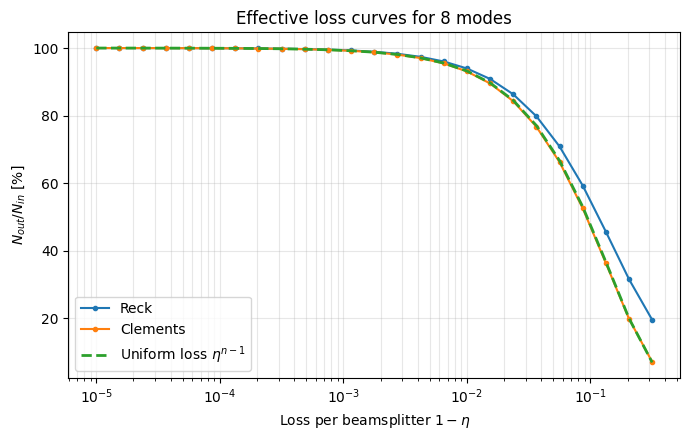

In [83]:
rng = np.random.default_rng(2027)
modes = 8
etas, N_in, curves = effective_loss_curve(modes, rng=rng)
loss = 1.0 - etas
uniform_percent = 100.0 * etas ** (modes - 1)

plt.figure(figsize=(7, 4.5))
for topo, vals in curves.items():
    plt.plot(loss, 100.0 * vals / N_in, marker='o', ms=3, lw=1.5, label=topo)
plt.plot(loss, uniform_percent, '--', lw=2, label=r'Uniform loss $\eta^{n-1}$')
plt.xscale('log')
plt.xlabel(r'Loss per beamsplitter $1-\eta$')
plt.ylabel(r'$N_{out} / N_{in}$ [%]')
plt.title(f'Effective loss curves for {modes} modes')
plt.grid(True, which='both', alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

### Mode-resolved photon-number distribution

A second useful visualization is the mode-resolved first-cumulant profile. The next cell compares

- the input state
- the lossless output state
- the lossy output state

for one fixed topology and one random target unitary.

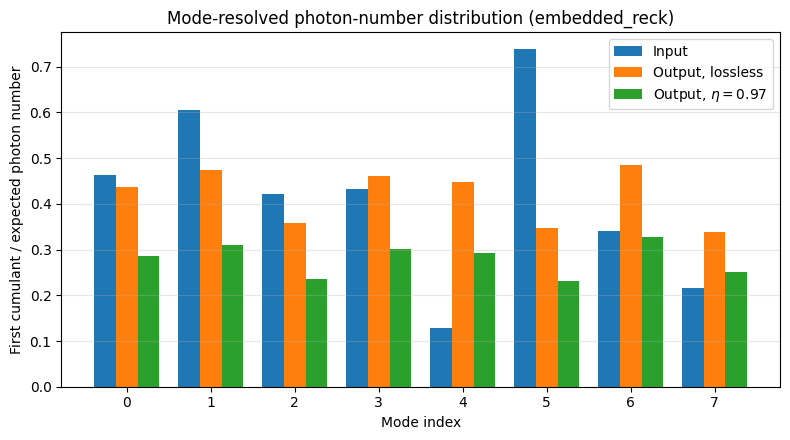

In [84]:
rng = np.random.default_rng(2028)
modes = 8
topology = 'embedded_reck'
eta_lossy = 0.97

U = haar_unitary(modes, rng)
d0, V0 = random_squeezed_vacuum(modes, rng=rng)

input_profile = GaussianDevice(d0.copy(), V0.copy(), instructions=()).first_cumulants()
d_lossless, V_lossless = get_Vout(U, V0, d0=d0, eta=1.0, topology=topology)
d_lossy, V_lossy = get_Vout(U, V0, d0=d0, eta=eta_lossy, topology=topology)
lossless_profile = GaussianDevice(d_lossless, V_lossless, instructions=()).first_cumulants()
lossy_profile = GaussianDevice(d_lossy, V_lossy, instructions=()).first_cumulants()

m = np.arange(modes)
width = 0.26

plt.figure(figsize=(8, 4.5))
plt.bar(m - width, input_profile, width=width, label='Input')
plt.bar(m, lossless_profile, width=width, label='Output, lossless')
plt.bar(m + width, lossy_profile, width=width, label=fr'Output, $\eta={eta_lossy}$')
plt.xlabel('Mode index')
plt.ylabel('First cumulant / expected photon number')
plt.title(f'Mode-resolved photon-number distribution ({topology})')
plt.xticks(m)
plt.grid(True, axis='y', alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## 9. A small parameter sweep

To close, here is a compact demonstration that the three topologies continue to agree in the lossless case across several mode numbers.

In [85]:
rng = np.random.default_rng(12345)

for modes in [3, 4, 6, 10, 16]:
    U = haar_unitary(modes, rng)
    d0, V0 = random_squeezed_vacuum(modes, rng=rng)

    _, V_c = get_Vout(U, V0, d0=d0, eta=1.0, topology='Clements')
    _, V_r = get_Vout(U, V0, d0=d0, eta=1.0, topology='Reck')
    _, V_e = get_Vout(U, V0, d0=d0, eta=1.0, topology='embedded_reck')

    print(f'modes={modes:2d}  |V_C-V_R|={np.linalg.norm(V_c - V_r):.3e}  |V_C-V_E|={np.linalg.norm(V_c - V_e):.3e}')

modes= 3  |V_C-V_R|=8.399e-16  |V_C-V_E|=8.399e-16
modes= 4  |V_C-V_R|=7.875e-16  |V_C-V_E|=7.875e-16
modes= 6  |V_C-V_R|=3.127e-15  |V_C-V_E|=3.116e-15
modes=10  |V_C-V_R|=3.530e-15  |V_C-V_E|=3.590e-15
modes=16  |V_C-V_R|=5.913e-15  |V_C-V_E|=5.850e-15


## Summary

The current LoGIC workflow is:

- use `GaussianDevice` when you already have an instruction list
- use `GaussianDevice.from_logical_state(...)` for convenient embedded-Reck ancilla handling
- use `get_Vout(...)` when you start from a target unitary
- use `embedded_total_modes` only when you want a larger physical Clements mesh than the default minimum `2*n - 2`

This notebook intentionally presents the current project state only, so it can be used as a practical starting point for experiments and further development.